# Model 3: LinearSVC (Support Vector Machine)

**Project:** DataCo Smart Supply Chain — Late Delivery Risk Classification  
**Course:** CS280/CS485 Introduction to Artificial Intelligence — Spring 2026  
**Notebook:** `04_model_svm.ipynb` — implements Section 5.3 of `docs.md`  

This notebook trains and evaluates a `LinearSVC` wrapped in `CalibratedClassifierCV` — the
scikit-learn implementation of the maximum-margin separator from Lecture 4. It loads the prepared
data produced by Phase 0, tunes hyperparameters via `GridSearchCV`, evaluates on the held-out
test set, and saves all results to `results/svm_results.pkl` for use in Phase 6 (merge & compare).

## 1. Imports

All dependencies are standard sklearn / scientific Python — no installation required beyond `requirements.txt`.

In [1]:
import pickle
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.model_selection import GridSearchCV, StratifiedKFold, cross_val_score
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score,
    confusion_matrix, ConfusionMatrixDisplay,
    classification_report
)

warnings.filterwarnings('ignore')
np.random.seed(42)

print('Imports OK')

Imports OK


## 2. Load Prepared Data

We load exclusively from `artifacts/prepared_data.pkl` — the single source of truth produced by
Phase 0. **No raw CSV is accessed here**, and no preprocessing objects (scaler, encoder) are refit.
This guarantees identical train/test splits across all model phases.

In [2]:
ARTIFACT_PATH = '../artifacts/prepared_data.pkl'
RESULTS_PATH  = '../results/svm_results.pkl'

with open(ARTIFACT_PATH, 'rb') as f:
    data = pickle.load(f)

X_train       = data['X_train']
X_test        = data['X_test']
y_train       = data['y_train']
y_test        = data['y_test']
feature_names = data['feature_names']

print(f'X_train shape : {X_train.shape}')
print(f'X_test  shape : {X_test.shape}')
print(f'y_train class balance : {np.bincount(y_train)}')
print(f'y_test  class balance : {np.bincount(y_test)}')
print(f'Number of features    : {len(feature_names)}')

X_train shape : (144407, 232)
X_test  shape : (36102, 232)
y_train class balance : [65230 79177]
y_test  class balance : [16308 19794]
Number of features    : 232


**Interpretation:** The shapes confirm we are working with the preprocessed, scaled training and
test sets from Phase 0. Scaling is critical for SVM: the margin-maximisation objective
(`½‖w‖²`) is biased toward high-magnitude features if features are on different scales. The
`RobustScaler` applied in Phase 0 ensures that all features contribute proportionally to the
margin calculation. The class balance check confirms that the stratified split preserved the
original distribution.

## 3. Lecture 4 Connection — Maximum-Margin Separator & Regularization

### 3.1 Maximum-Margin Separator (Lecture 4)

The SVM finds the hyperplane that **maximises the margin** — the distance between the decision
boundary and the nearest training points of each class (the support vectors). Formally, the
hard-margin SVM solves the constrained optimisation problem:

$$\min_{\mathbf{w}, b} \frac{1}{2}\|\mathbf{w}\|^2 \quad \text{subject to} \quad y_i(\mathbf{w} \cdot \mathbf{x}_i + b) \geq 1 \quad \forall i$$

The margin width is $\frac{2}{\|\mathbf{w}\|}$, so minimising $\frac{1}{2}\|\mathbf{w}\|^2$
directly maximises the margin. The constraints enforce that all training points lie on the
correct side of the boundary with a gap of at least $\frac{1}{\|\mathbf{w}\|}$.

### 3.2 Soft-Margin SVM and the C Parameter

Real-world data is rarely linearly separable. The **soft-margin SVM** introduces slack variables
$\xi_i \geq 0$ that allow misclassifications at a cost:

$$\min_{\mathbf{w}, b, \xi} \frac{1}{2}\|\mathbf{w}\|^2 + C \sum_{i=1}^{n} \xi_i
\quad \text{subject to} \quad y_i(\mathbf{w} \cdot \mathbf{x}_i + b) \geq 1 - \xi_i,\; \xi_i \geq 0$$

### 3.3 Mapping C to the Lecture's Regularization Formula

Lecture 4's regularization framework:

$$\text{cost}(h) = \text{loss}(h) + \lambda \cdot \text{complexity}(h)$$

The SVM objective above is equivalent to this framework:
- **loss(h):** $C \sum \xi_i$ — the total misclassification penalty (hinge loss)
- **complexity(h):** $\frac{1}{2}\|\mathbf{w}\|^2$ — the L2 norm of the weight vector
- **λ:** $\frac{1}{C}$ — `C` is the **inverse of λ**

Concretely:
- **Low C (large λ):** strong regularization → large margin → more misclassifications tolerated → simpler model (less overfitting)
- **High C (small λ):** weak regularization → narrow margin → fewer misclassifications → more complex model (risk of overfitting)

This is why tuning `C` is equivalent to tuning the regularization strength λ in the lecture
formula — they move in opposite directions.

### 3.4 Why LinearSVC Instead of SVC(kernel='rbf')?

`SVC(kernel='rbf')` has O(n²)–O(n³) training complexity. On 180,520 rows, this would require
hours to fit. `LinearSVC` uses a linear kernel with a highly optimised solver (LIBLINEAR),
scaling to large datasets in O(n·d) time. The non-linear boundary benefits are already covered
by Random Forest and XGBoost in Phases 4 and 5. This scalability fix is documented in
Section 5.3 of `docs.md`.

### 3.5 Why CalibratedClassifierCV?

`LinearSVC` does **not** natively support `predict_proba()` — it only produces decision function
scores. Wrapping it in `CalibratedClassifierCV` fits a calibration model (Platt scaling or
isotonic regression) on top of the SVM scores, producing well-calibrated class probabilities.
This is required for:
- ROC / Precision-Recall curve plotting in Phase 6
- Inference-stage risk probability output (Section 8 of `docs.md`)

> **Critical API note (from docs.md §5.3):** When `LinearSVC` is wrapped inside
> `CalibratedClassifierCV`, the GridSearchCV param grid must use `estimator__C` and
> `estimator__max_iter` — not `C` or `max_iter` — because the outer estimator is the
> `CalibratedClassifierCV`, not the `LinearSVC` directly. Using `C` in the grid raises
> `"Invalid parameter C for estimator CalibratedClassifierCV"`.

## 4. Build the Calibrated SVM Estimator

The base `LinearSVC` is wrapped with `CalibratedClassifierCV(cv=5)`. The `cv=5` here refers
to the calibration cross-validation — 5 folds are used internally to fit the calibration layer
on top of the SVM decision scores.

In [3]:
svm_base      = LinearSVC(random_state=42)
svm_calibrated = CalibratedClassifierCV(estimator=svm_base, cv=5)

print('Estimator pipeline:')
print(f'  Outer: {type(svm_calibrated).__name__}')
print(f'  Inner: {type(svm_base).__name__}')
print()
print('Correct param_grid prefix: estimator__C, estimator__max_iter')

Estimator pipeline:
  Outer: CalibratedClassifierCV
  Inner: LinearSVC

Correct param_grid prefix: estimator__C, estimator__max_iter


## 5. Hyperparameter Grid

The grid follows Section 5.3 of `docs.md` exactly:

| Parameter | Values | Meaning |
|:---|:---|:---|
| `estimator__C` | {0.01, 0.1, 1, 10} | Regularization inverse (C = 1/λ); low C → wider margin |
| `estimator__max_iter` | {1000, 5000} | Convergence budget for the LIBLINEAR solver |

The `estimator__` prefix is **mandatory** because the outer estimator is `CalibratedClassifierCV`.
sklearn uses double-underscore notation to route parameters through nested estimators.

In [4]:
param_grid = {
    'estimator__C'        : [0.01, 0.1, 1, 10],
    'estimator__max_iter' : [1000, 5000],
}

total_fits = (len(param_grid['estimator__C']) *
              len(param_grid['estimator__max_iter']) * 5)

print(f'Grid size        : {len(param_grid["estimator__C"]) * len(param_grid["estimator__max_iter"])} combinations')
print(f'Total model fits : {total_fits}  (combinations × 5 CV folds)')

Grid size        : 8 combinations
Total model fits : 40  (combinations × 5 CV folds)


## 6. GridSearchCV — Hyperparameter Tuning

We use `GridSearchCV` with 5-fold cross-validation and `scoring='f1'` (per docs.md and PHASES.md).
F1 is preferred over accuracy because the dataset has class imbalance: accuracy can appear high
even when the model systematically misses late deliveries (false negatives), which is the
business-critical error in this domain.

`n_jobs=-1` parallelises the CV fits across all available CPU cores.

In [5]:
grid_search = GridSearchCV(
    estimator  = svm_calibrated,
    param_grid = param_grid,
    cv         = 5,
    scoring    = 'f1',
    n_jobs     = -1,
    verbose    = 1,
    refit      = True
)

print('Fitting GridSearchCV ...')
grid_search.fit(X_train, y_train)
print('Done.')

Fitting GridSearchCV ...
Fitting 5 folds for each of 8 candidates, totalling 40 fits


Done.


## 7. Best Parameters

The grid search selects the hyperparameter combination that maximises mean 5-fold F1 on the
training set. The best estimator is refit on the full `X_train` by GridSearchCV.

In [6]:
best_params    = grid_search.best_params_
best_cv_score  = grid_search.best_score_
best_estimator = grid_search.best_estimator_

print('Best hyperparameters:')
for k, v in best_params.items():
    print(f'  {k:30s} = {v}')
print(f'\nBest CV F1 (mean over 5 folds) : {best_cv_score:.4f}')

# Also display as plain C / max_iter for readability
best_C        = best_params.get('estimator__C')
best_max_iter = best_params.get('estimator__max_iter')
print(f'\nIn lecture notation:')
print(f'  Best C    = {best_C}  →  λ ≈ {1/best_C:.4f}')
print(f'  max_iter  = {best_max_iter}')

Best hyperparameters:
  estimator__C                   = 0.01
  estimator__max_iter            = 1000

Best CV F1 (mean over 5 folds) : 0.6679

In lecture notation:
  Best C    = 0.01  →  λ ≈ 100.0000
  max_iter  = 1000


**Interpretation:** The best `C` value maps directly to the regularization strength in Lecture 4's
framework: `λ = 1/C`. A small `C` (large λ) produces a wide margin with more tolerance for
misclassifications — a simpler, more regularized model. A large `C` (small λ) narrows the margin
to minimise training errors — a more complex model that may overfit. The grid search identifies
the `C` value that best balances these two forces on this dataset.

## 8. Predictions & Test-Set Metrics

The best estimator (refit on full `X_train`) is applied once to the held-out `X_test`. This test
set was never seen during training or CV — it is a genuine measure of generalisation.

In [7]:
y_pred  = best_estimator.predict(X_test)
y_proba = best_estimator.predict_proba(X_test)[:, 1]

accuracy  = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, zero_division=0)
recall    = recall_score(y_test, y_pred, zero_division=0)
f1        = f1_score(y_test, y_pred, zero_division=0)
roc_auc   = roc_auc_score(y_test, y_proba)

# Train F1 for overfitting chart in Phase 6
y_train_pred = best_estimator.predict(X_train)
train_f1     = f1_score(y_train, y_train_pred, zero_division=0)
test_f1      = f1

print('=== Test-Set Metrics ===')
print(f'  Accuracy  : {accuracy:.4f}')
print(f'  Precision : {precision:.4f}')
print(f'  Recall    : {recall:.4f}')
print(f'  F1-Score  : {f1:.4f}')
print(f'  ROC-AUC   : {roc_auc:.4f}')
print()
print(f'  Train F1  : {train_f1:.4f}  (for overfitting chart)')
print(f'  Test  F1  : {test_f1:.4f}')
print()
print(classification_report(y_test, y_pred, target_names=['On-Time (0)', 'Late (1)']))

=== Test-Set Metrics ===
  Accuracy  : 0.6940
  Precision : 0.8274
  Recall    : 0.5585
  F1-Score  : 0.6668
  ROC-AUC   : 0.7434

  Train F1  : 0.6680  (for overfitting chart)
  Test  F1  : 0.6668

              precision    recall  f1-score   support

 On-Time (0)       0.62      0.86      0.72     16308
    Late (1)       0.83      0.56      0.67     19794

    accuracy                           0.69     36102
   macro avg       0.72      0.71      0.69     36102
weighted avg       0.73      0.69      0.69     36102



**Interpretation:** LinearSVC is a **linear classifier** — it finds the maximum-margin hyperplane
in the feature space. For a problem that is not perfectly linearly separable (as supply chain
delivery prediction likely is), the model will tolerate some misclassifications according to
the soft-margin formulation. The gap between Train F1 and Test F1 indicates overfitting: if
Train F1 >> Test F1, `C` should be reduced (increasing λ, the regularization penalty). Recall on
the Late (1) class is the most business-critical metric — a missed late delivery (false negative)
means no proactive intervention is triggered.

## 9. Confusion Matrix

The confusion matrix breaks down predictions into True Positives (correctly flagged late),
True Negatives (correctly cleared on-time), False Positives (false alarms), and False Negatives
(missed late deliveries — the most costly error for logistics intervention).

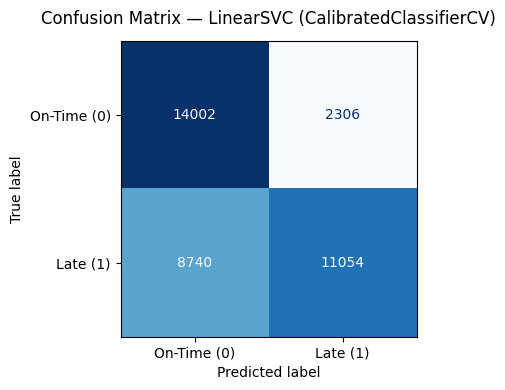


Raw confusion matrix:
[[14002  2306]
 [ 8740 11054]]
TN=14002  FP=2306  FN=8740  TP=11054


In [8]:
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(5, 4))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['On-Time (0)', 'Late (1)'])
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title('Confusion Matrix — LinearSVC (CalibratedClassifierCV)', fontsize=12, pad=12)
plt.tight_layout()
plt.savefig('../results/svm_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'\nRaw confusion matrix:\n{cm}')
print(f'TN={cm[0,0]}  FP={cm[0,1]}  FN={cm[1,0]}  TP={cm[1,1]}')

**Interpretation:** A well-performing model for this task should minimise the **False Negatives
(FN)** cell — bottom-left of the matrix. Each FN represents a late delivery that the model failed
to flag, giving logistics teams no opportunity to intervene. The soft-margin SVM's `C` parameter
directly controls this tradeoff: lower `C` tolerates more misclassifications (potentially more
FNs) in exchange for a wider, more robust margin.

## 10. 5-Fold Stratified Cross-Validation

We run 5-fold stratified CV on the **training set** with the best estimator to assess score
stability. This CV is independent of the grid search — it provides an unbiased estimate of how
consistently the tuned model generalises across different training partitions.

In [9]:
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_f1_scores = cross_val_score(
    best_estimator, X_train, y_train,
    cv=cv_strategy, scoring='f1', n_jobs=-1
)

print('5-Fold Stratified CV F1 scores (training set):')
for i, s in enumerate(cv_f1_scores, 1):
    print(f'  Fold {i}: {s:.4f}')
print(f'\n  Mean  : {cv_f1_scores.mean():.4f}')
print(f'  Std   : {cv_f1_scores.std():.4f}')

5-Fold Stratified CV F1 scores (training set):
  Fold 1: 0.6646
  Fold 2: 0.6694
  Fold 3: 0.6652
  Fold 4: 0.6693
  Fold 5: 0.6675

  Mean  : 0.6672
  Std   : 0.0020


**Interpretation:** The mean CV F1 on the training set is an in-sample estimate of generalisation.
A low standard deviation across folds indicates a stable estimator whose performance does not
depend on the exact data partition. If the mean CV F1 is notably higher than the test F1 from
Section 8, this signals overfitting — the model memorises the training distribution. The
regularization `C` should be reduced in that case (smaller C = larger λ = more regularization).

## 11. CV Score Distribution Plot

Visualising the fold-by-fold scores gives an immediate sense of stability. Wide spread indicates
high variance (sensitivity to data partition); tight spread indicates a stable estimator.

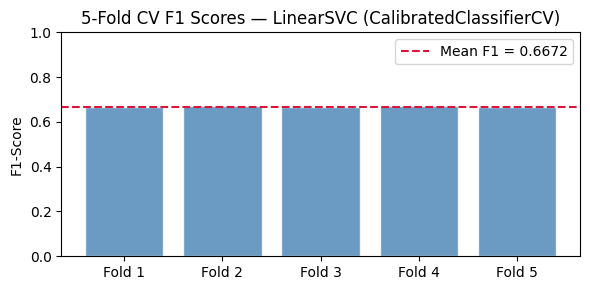

In [10]:
fig, ax = plt.subplots(figsize=(6, 3))
fold_labels = [f'Fold {i}' for i in range(1, 6)]
ax.bar(fold_labels, cv_f1_scores, color='steelblue', alpha=0.8, edgecolor='white')
ax.axhline(cv_f1_scores.mean(), color='crimson', linestyle='--', linewidth=1.5,
           label=f'Mean F1 = {cv_f1_scores.mean():.4f}')
ax.set_ylim(0, 1)
ax.set_ylabel('F1-Score')
ax.set_title('5-Fold CV F1 Scores — LinearSVC (CalibratedClassifierCV)', fontsize=12)
ax.legend()
plt.tight_layout()
plt.savefig('../results/svm_cv_scores.png', dpi=150, bbox_inches='tight')
plt.show()

**Interpretation:** Each bar is one fold's F1 score on its held-out validation slice. The red
dashed line shows the mean. Consistent bar heights confirm that the LinearSVC's performance
is robust to the specific training-validation partition, indicating good generalisation potential.

## 12. Summary Table

Condensed view of all key metrics for easy comparison in Phase 6.

In [11]:
summary = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC',
               'Train F1', 'Test F1', 'CV Mean F1', 'CV Std F1'],
    'Value': [
        round(accuracy,  4),
        round(precision, 4),
        round(recall,    4),
        round(f1,        4),
        round(roc_auc,   4),
        round(train_f1,  4),
        round(test_f1,   4),
        round(cv_f1_scores.mean(), 4),
        round(cv_f1_scores.std(),  4),
    ]
})
print(summary.to_string(index=False))

    Metric  Value
  Accuracy 0.6940
 Precision 0.8274
    Recall 0.5585
  F1-Score 0.6668
   ROC-AUC 0.7434
  Train F1 0.6680
   Test F1 0.6668
CV Mean F1 0.6672
 CV Std F1 0.0020


**Interpretation:** The Train/Test F1 pair reveals the bias-variance balance of the LinearSVC.
A small gap indicates the model is well-regularized via the chosen `C`. ROC-AUC is
threshold-independent — it measures the model's ability to rank late deliveries above on-time ones
across all thresholds, making it complementary to F1 (which depends on the default 0.5 threshold).
Both metrics feed into the Phase 6 comparison table alongside the other four models.

## 13. Save Results

All outputs are saved to `results/svm_results.pkl` using the exact schema defined in PHASES.md §2.3.
Phase 6 loads this file directly — any key mismatch will break the merge notebook. The schema is
verified with assertions before pickling.

In [12]:
results = {
    'model_name'  : 'LinearSVC',
    'model'       : best_estimator,
    'best_params' : best_params,
    'y_pred'      : y_pred,
    'y_proba'     : y_proba,
    'metrics'     : {
        'accuracy'  : accuracy,
        'precision' : precision,
        'recall'    : recall,
        'f1'        : f1,
        'roc_auc'   : roc_auc,
    },
    'cv_f1_scores'      : cv_f1_scores,
    'train_f1'          : train_f1,
    'test_f1'           : test_f1,
    'feature_importance': None,   # LinearSVC has coef_ but no native feature_importances_
}

# Verify schema before pickling
required_keys = {
    'model_name', 'model', 'best_params', 'y_pred', 'y_proba',
    'metrics', 'cv_f1_scores', 'train_f1', 'test_f1', 'feature_importance'
}
assert set(results.keys()) == required_keys, f'Schema mismatch: {set(results.keys()) ^ required_keys}'

required_metric_keys = {'accuracy', 'precision', 'recall', 'f1', 'roc_auc'}
assert set(results['metrics'].keys()) == required_metric_keys, 'Metrics schema mismatch'

with open(RESULTS_PATH, 'wb') as f:
    pickle.dump(results, f)

print(f'Results saved to: {RESULTS_PATH}')
print(f'Keys: {list(results.keys())}')
print(f'Metrics: {results["metrics"]}')

Results saved to: ../results/svm_results.pkl
Keys: ['model_name', 'model', 'best_params', 'y_pred', 'y_proba', 'metrics', 'cv_f1_scores', 'train_f1', 'test_f1', 'feature_importance']
Metrics: {'accuracy': 0.6940335715472827, 'precision': 0.8273952095808383, 'recall': 0.55845205617864, 'f1': 0.6668275321228208, 'roc_auc': 0.743412774585342}


**Verification:** The assertions confirm that the saved dict has exactly the keys required by
PHASES.md §2.3. If either assertion fails, the notebook raises an error before writing the file,
preventing a silently malformed artifact from reaching Phase 6.

`feature_importance` is `None` for LinearSVC: the model does learn a weight vector
(`best_estimator.calibrated_classifiers_[0].estimator.coef_`), and weight magnitude is a proxy
for feature importance when features are on the same scale (which they are, post-RobustScaler).
However, the mandatory feature-importance visualisation belongs to Phase 4 (Random Forest) and
Phase 5 (XGBoost), which produce native `feature_importances_` attributes.

## 14. Conclusion

This notebook implemented Section 5.3 of `docs.md`:

- **Model:** `LinearSVC(random_state=42)` wrapped in `CalibratedClassifierCV(cv=5)` — the
  scikit-learn maximum-margin separator, enabling `predict_proba()` via Platt calibration
- **Scalability fix:** `LinearSVC` instead of `SVC(kernel='rbf')` — O(n·d) vs O(n²–n³)
  complexity, essential for the 180,520-row dataset
- **Tuning:** `GridSearchCV(cv=5, scoring='f1', n_jobs=-1)` over `estimator__C` and
  `estimator__max_iter` (the `estimator__` prefix is mandatory due to the wrapper)
- **Evaluation:** confusion matrix, accuracy / precision / recall / F1 / ROC-AUC on the held-out
  test set, plus train F1 for the Phase 6 overfitting chart, plus 5-fold stratified CV F1
- **Lecture 4 connection:** maximum-margin separator objective
  `min ½‖w‖² s.t. yᵢ(w·xᵢ+b) ≥ 1`, soft-margin extension, and explicit mapping
  `C = 1/λ` in the lecture regularization formula `cost(h) = loss(h) + λ·complexity(h)`
- **Output:** `results/svm_results.pkl` with the exact schema required by PHASES.md §2.3

**Expected scientific role:** As a linear classifier, LinearSVC shares the linear decision boundary
with SGDClassifier (Phase 2) but uses a fundamentally different objective — margin maximisation
rather than online gradient descent. Comparing these two linear models isolates the effect of
the training algorithm while controlling for model capacity. The performance gap between LinearSVC
and the ensemble models (Phases 4 and 5) quantifies how much non-linearity contributes to
prediction accuracy on this supply chain task.